In [4]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

Text(0, 0.5, 'Y dataset')

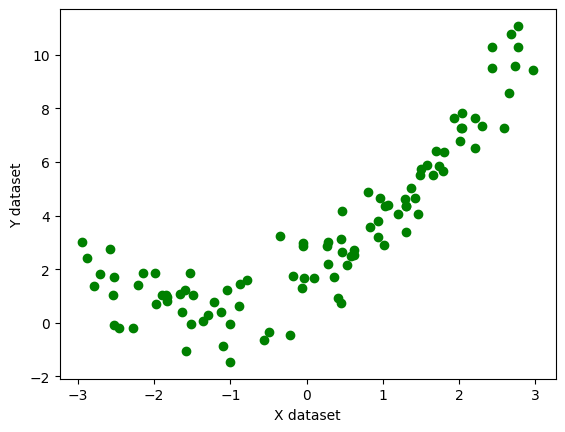

In [11]:
# create non linear random datasets using quadratic eq.
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [14]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.39]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.09]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[14.75]


In [15]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.6890406495101747


Text(0, 0.5, 'Y')

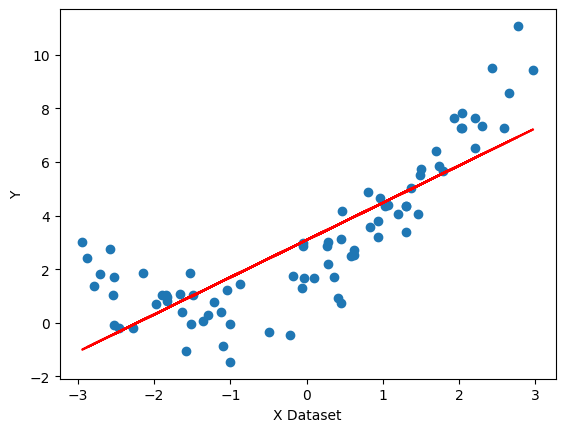

In [16]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")


In [17]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
# linear regresion : h(x)= b0 + b1x1
# Degree 2 plynomial regression : h(x)= b0 + b1x1 + b2x1^2 , if it good then used this otherwise shift to degree=3
# Degree 3 plynomial regression : h(x)= b0 + b1x1 + b2x1^3

In [18]:
poly=PolynomialFeatures(degree=2,include_bias=True)  # include_bias means include b0^1 also
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [19]:
X_train_poly
# each row has three value with coff of b0(constant) and x1(i.e b1) and x1^2(i.e b2) 
# columns 3 is just square of column 1 

array([[ 1.00000000e+00, -2.70883634e+00,  7.33779433e+00],
       [ 1.00000000e+00,  2.96900326e+00,  8.81498035e+00],
       [ 1.00000000e+00,  1.06687571e+00,  1.13822377e+00],
       [ 1.00000000e+00,  1.78852718e+00,  3.19882948e+00],
       [ 1.00000000e+00, -1.52849514e+00,  2.33629740e+00],
       [ 1.00000000e+00, -4.88287058e-01,  2.38424251e-01],
       [ 1.00000000e+00,  9.39696275e-01,  8.83029090e-01],
       [ 1.00000000e+00,  1.49375051e+00,  2.23129060e+00],
       [ 1.00000000e+00,  2.80357715e-01,  7.86004485e-02],
       [ 1.00000000e+00,  1.73465874e+00,  3.00904093e+00],
       [ 1.00000000e+00, -2.79288834e+00,  7.80022526e+00],
       [ 1.00000000e+00, -1.65847974e+00,  2.75055503e+00],
       [ 1.00000000e+00,  2.03776466e+00,  4.15248480e+00],
       [ 1.00000000e+00, -1.75438170e-01,  3.07785517e-02],
       [ 1.00000000e+00,  1.02038505e+00,  1.04118565e+00],
       [ 1.00000000e+00, -2.14216573e+00,  4.58887400e+00],
       [ 1.00000000e+00,  1.29957359e+00

In [20]:
X_test_poly

array([[ 1.        ,  2.42582374,  5.88462081],
       [ 1.        ,  2.76749374,  7.65902163],
       [ 1.        ,  0.53426519,  0.28543929],
       [ 1.        ,  1.79451022,  3.22026692],
       [ 1.        , -0.88470232,  0.7826982 ],
       [ 1.        , -0.78241464,  0.61217267],
       [ 1.        ,  1.58397134,  2.50896521],
       [ 1.        ,  1.42686393,  2.03594067],
       [ 1.        ,  1.28575703,  1.65317113],
       [ 1.        ,  0.45950177,  0.21114188],
       [ 1.        ,  1.65590584,  2.74202416],
       [ 1.        , -2.21371644,  4.90054048],
       [ 1.        , -0.5643644 ,  0.31850718],
       [ 1.        , -1.59493667,  2.54382299],
       [ 1.        ,  2.67329618,  7.14651244],
       [ 1.        , -0.34670046,  0.12020121],
       [ 1.        ,  2.01568072,  4.06296877],
       [ 1.        ,  1.01703139,  1.03435285],
       [ 1.        , -1.99306964,  3.97232657],
       [ 1.        ,  2.73497112,  7.48006703]])

In [21]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9310400165576076


In [22]:
print(regression.coef_)
# here three value as we have three features now

[[0.         1.50547529 0.52744437]]


In [23]:
print(regression.intercept_)

[1.65684528]


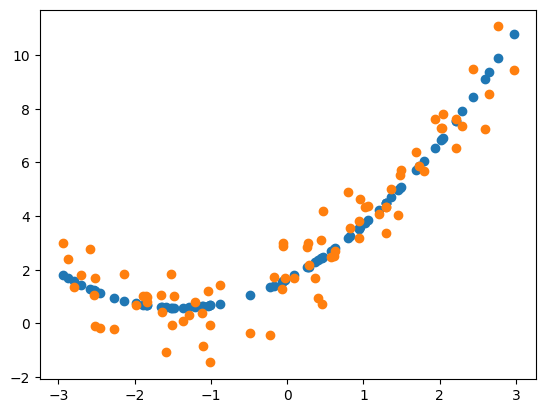

In [24]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [25]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [26]:
X_train_poly
# now we have 4 features , b0, b1, b2,b3 i.e coefficient of x^0, x^1, x^2 and x^3.

array([[ 1.00000000e+00, -2.70883634e+00,  7.33779433e+00,
        -1.98768839e+01],
       [ 1.00000000e+00,  2.96900326e+00,  8.81498035e+00,
         2.61717054e+01],
       [ 1.00000000e+00,  1.06687571e+00,  1.13822377e+00,
         1.21434329e+00],
       [ 1.00000000e+00,  1.78852718e+00,  3.19882948e+00,
         5.72119348e+00],
       [ 1.00000000e+00, -1.52849514e+00,  2.33629740e+00,
        -3.57101922e+00],
       [ 1.00000000e+00, -4.88287058e-01,  2.38424251e-01,
        -1.16419476e-01],
       [ 1.00000000e+00,  9.39696275e-01,  8.83029090e-01,
         8.29779146e-01],
       [ 1.00000000e+00,  1.49375051e+00,  2.23129060e+00,
         3.33299148e+00],
       [ 1.00000000e+00,  2.80357715e-01,  7.86004485e-02,
         2.20362422e-02],
       [ 1.00000000e+00,  1.73465874e+00,  3.00904093e+00,
         5.21965913e+00],
       [ 1.00000000e+00, -2.79288834e+00,  7.80022526e+00,
        -2.17851582e+01],
       [ 1.00000000e+00, -1.65847974e+00,  2.75055503e+00,
      

In [27]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9136115800432514


# 3 Prediction of new data set

In [28]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

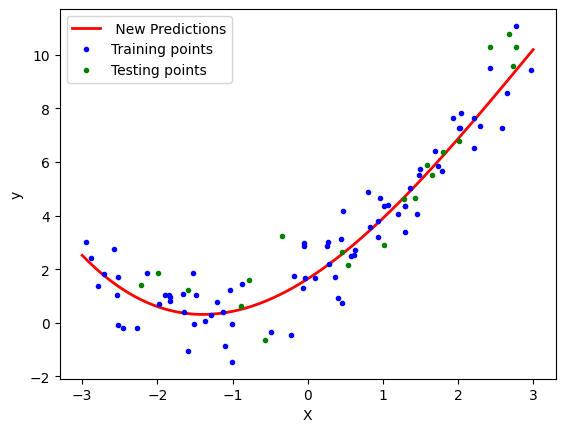

In [29]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts 

In [30]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    # this pipeline first do polynomial features and then go for lin _regression on thoses features
    
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

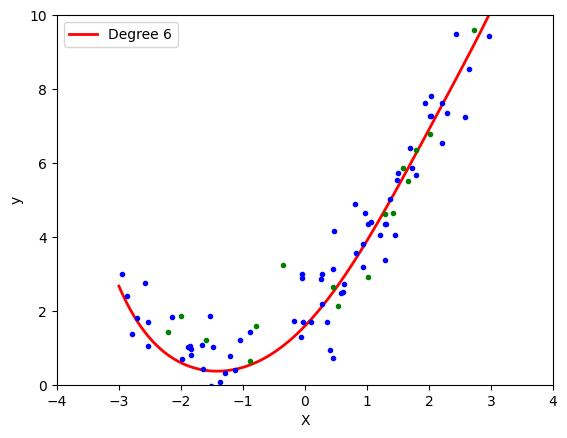

In [32]:
poly_regression(6)

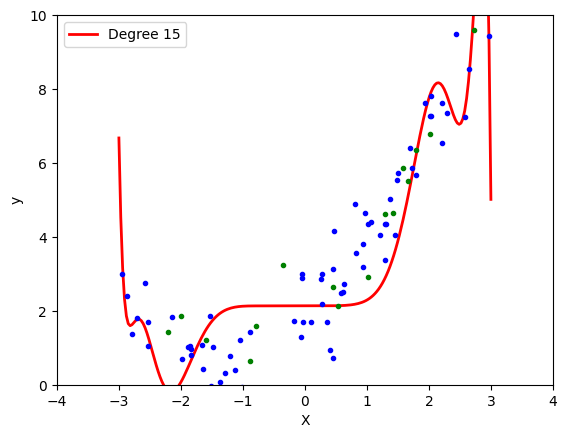

In [33]:
poly_regression(15)